# Atlassian Datathon — Targeted EDA

This notebook focuses on five questions:

- Which plans / company sizes have the worst support experience?
- Which products have lots of tickets and low CSAT?
- Do low-CSAT customers use Atlassian less?
- Are Premium / Enterprise customers more engaged but also more exposed to poor support?
- Which customer group gives us the clearest story?


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


C:\Users\Maxim\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load data

In [2]:
customers = pd.read_csv("data/customers.csv")
tickets = pd.read_csv("data/customer_support_tickets.csv")
usage = pd.read_csv("data/product_usage.csv")

usage["Month"] = pd.to_datetime(usage["Month"])
tickets["First Response Time"] = pd.to_datetime(
    tickets["First Response Time"], dayfirst=True, errors="coerce"
)

print("Customers:", customers.shape)
print("Tickets:", tickets.shape)
print("Usage:", usage.shape)


Customers: (8320, 10)
Tickets: (8469, 16)
Usage: (42210, 8)


## Join tickets to customer info

In [3]:
tickets_customer = tickets.merge(
    customers[[
        "Customer ID",
        "Customer Email",
        "Plan Type",
        "Industry",
        "Region",
        "Company Size"
    ]],
    on="Customer Email",
    how="left",
    validate="many_to_one"
)

print(
    "Ticket -> customer match rate:",
    round(tickets_customer["Customer ID"].notna().mean() * 100, 2),
    "%"
)

tickets_customer.head()


Ticket -> customer match rate: 100.0 %


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Customer ID,Plan Type,Industry,Region,Company Size
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:00,NaN,NaN,CUST01085,Free,Technology,Europe,1000+
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:00,NaN,NaN,CUST01335,Standard,Financial Services,North America,11-50
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:00,01-06-2023 18:05,3.00,CUST02581,Premium,Media & Communications,North America,201-500
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:00,01-06-2023 01:57,3.00,CUST00742,Premium,Professional Services,Australia & New Zealand,51-200
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:00,01-06-2023 19:53,1.00,CUST00741,Enterprise,Manufacturing,Australia & New Zealand,501-1000


## 1. Which plan has the worst support experience?

I’m looking at:
- ticket burden
- average CSAT
- low CSAT rate
- critical ticket rate
- closed ticket rate


In [4]:
def support_summary(df, group_col):
    return (
        df.groupby(group_col)
        .agg(
            customers=("Customer ID", "nunique"),
            tickets=("Ticket ID", "count"),
            avg_csat=("Customer Satisfaction Rating", "mean"),
            low_csat_pct=(
                "Customer Satisfaction Rating",
                lambda x: (x.dropna() <= 2).mean() * 100
                if x.notna().any() else np.nan
            ),
            critical_pct=(
                "Ticket Priority",
                lambda x: (x == "Critical").mean() * 100
            ),
            closed_pct=(
                "Ticket Status",
                lambda x: (x == "Closed").mean() * 100
            )
        )
        .assign(
            tickets_per_customer=lambda x: x["tickets"] / x["customers"]
        )
        .round(2)
        .sort_values("avg_csat")
    )

plan_support = support_summary(tickets_customer, "Plan Type")
plan_support


,customers,tickets,avg_csat,low_csat_pct,critical_pct,closed_pct,tickets_per_customer
Plan Type,,,,,,,
Standard,3309,3367,2.96,41.55,25.07,32.88,1.02
Premium,2337,2383,2.99,38.52,24.72,32.35,1.02
Free,1472,1506,3.02,38.96,26.03,33.07,1.02
Enterprise,1202,1213,3.04,38.42,25.06,32.40,1.01


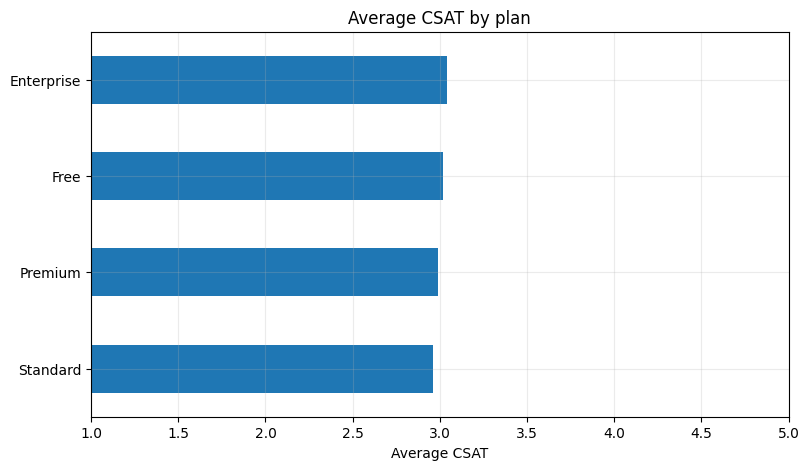

In [5]:
plan_support["avg_csat"].sort_values().plot(kind="barh")
plt.title("Average CSAT by plan")
plt.xlabel("Average CSAT")
plt.ylabel("")
plt.xlim(1, 5)
plt.show()


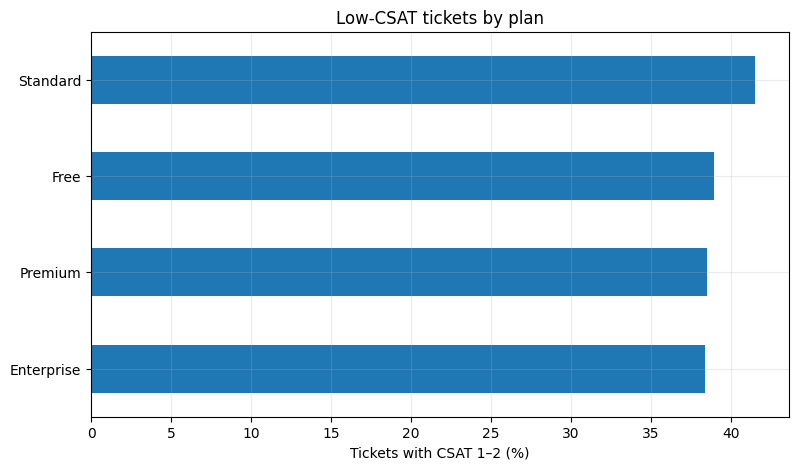

In [6]:
plan_support["low_csat_pct"].sort_values().plot(kind="barh")
plt.title("Low-CSAT tickets by plan")
plt.xlabel("Tickets with CSAT 1–2 (%)")
plt.ylabel("")
plt.show()


## Which company size has the worst support experience?

In [7]:
company_support = support_summary(tickets_customer, "Company Size")
company_support


,customers,tickets,avg_csat,low_csat_pct,critical_pct,closed_pct,tickets_per_customer
Company Size,,,,,,,
51-200,2322,2365,2.91,42.97,25.92,33.07,1.02
1000+,950,973,2.92,40.94,23.12,30.63,1.02
1-10,875,891,3.02,38.65,23.12,31.65,1.02
201-500,1502,1522,3.04,39.16,27.00,34.56,1.01
501-1000,896,911,3.04,37.87,23.82,33.04,1.02
11-50,1775,1807,3.06,37.07,25.29,32.10,1.02


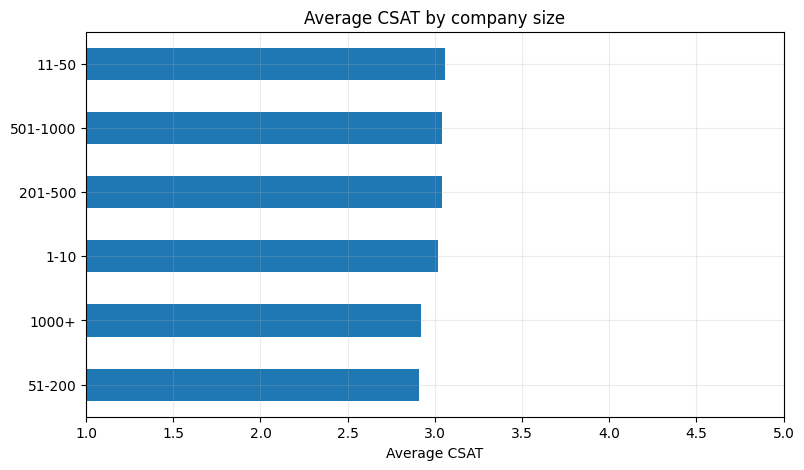

In [8]:
company_support["avg_csat"].sort_values().plot(kind="barh")
plt.title("Average CSAT by company size")
plt.xlabel("Average CSAT")
plt.ylabel("")
plt.xlim(1, 5)
plt.show()


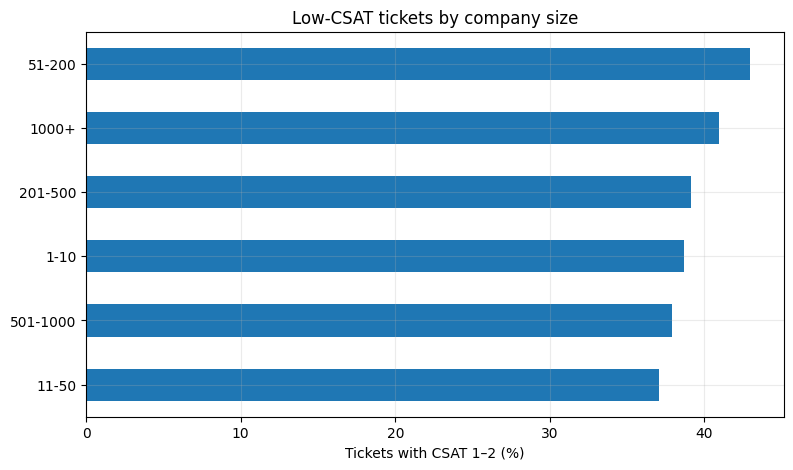

In [9]:
company_support["low_csat_pct"].sort_values().plot(kind="barh")
plt.title("Low-CSAT tickets by company size")
plt.xlabel("Tickets with CSAT 1–2 (%)")
plt.ylabel("")
plt.show()


## 2. Which product has high ticket volume and low CSAT?

A product is more interesting if it has both:
- lots of support tickets
- weak satisfaction


In [10]:
product_support = (
    tickets.groupby("Product Purchased")
    .agg(
        tickets=("Ticket ID", "count"),
        ticket_customers=("Customer Email", "nunique"),
        avg_csat=("Customer Satisfaction Rating", "mean"),
        low_csat_pct=(
            "Customer Satisfaction Rating",
            lambda x: (x.dropna() <= 2).mean() * 100
            if x.notna().any() else np.nan
        ),
        critical_pct=(
            "Ticket Priority",
            lambda x: (x == "Critical").mean() * 100
        ),
        open_or_pending_pct=(
            "Ticket Status",
            lambda x: (x != "Closed").mean() * 100
        )
    )
    .round(2)
    .sort_values(["avg_csat", "tickets"], ascending=[True, False])
)

product_support


,tickets,ticket_customers,avg_csat,low_csat_pct,critical_pct,open_or_pending_pct
Product Purchased,,,,,,
Bitbucket,1595,1590,2.94,40.99,25.02,66.96
Jira,1787,1779,2.96,39.97,24.01,67.38
Trello,1627,1621,2.97,39.89,27.60,65.95
Confluence,1831,1825,3.02,38.90,23.98,69.25
Loom,1629,1627,3.06,39.30,25.35,66.73


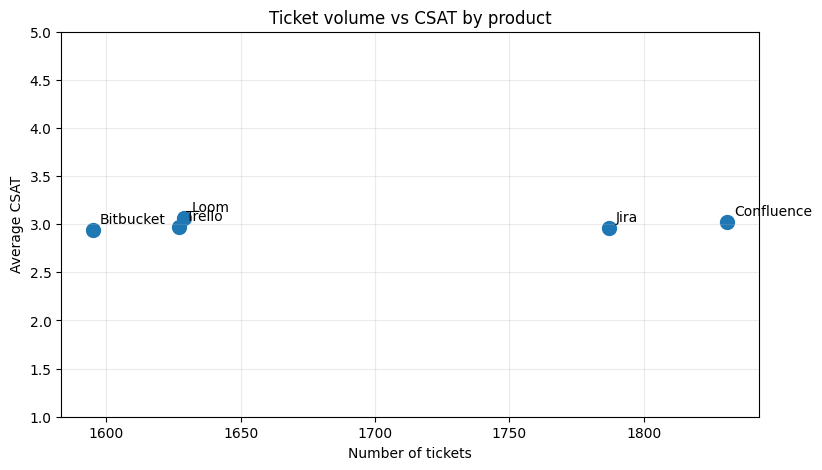

In [11]:
fig, ax = plt.subplots()

ax.scatter(
    product_support["tickets"],
    product_support["avg_csat"],
    s=100
)

for product, row in product_support.iterrows():
    ax.annotate(
        product,
        (row["tickets"], row["avg_csat"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_title("Ticket volume vs CSAT by product")
ax.set_xlabel("Number of tickets")
ax.set_ylabel("Average CSAT")
ax.set_ylim(1, 5)

plt.show()


A product in the **bottom-right** of this chart is the most interesting: high ticket volume + low CSAT.

## Ticket burden relative to product usage

In [12]:
product_usage_customers = (
    usage.groupby("Product")
    .agg(
        usage_customers=("Customer ID", "nunique"),
        avg_sessions=("Sessions", "mean"),
        avg_actions=("Product Actions", "mean")
    )
    .reset_index()
)

product_support_full = (
    product_support.reset_index()
    .merge(
        product_usage_customers,
        left_on="Product Purchased",
        right_on="Product",
        how="left"
    )
)

product_support_full["tickets_per_100_usage_customers"] = (
    product_support_full["tickets"]
    / product_support_full["usage_customers"]
    * 100
)

product_support_full[[
    "Product Purchased",
    "tickets",
    "usage_customers",
    "tickets_per_100_usage_customers",
    "avg_csat",
    "low_csat_pct",
    "critical_pct"
]].round(2).sort_values(
    "tickets_per_100_usage_customers",
    ascending=False
)


,Product Purchased,tickets,usage_customers,tickets_per_100_usage_customers,avg_csat,low_csat_pct,critical_pct
1,Jira,1787,1779,100.45,2.96,39.97,24.01
2,Trello,1627,1621,100.37,2.97,39.89,27.60
3,Confluence,1831,1825,100.33,3.02,38.90,23.98
0,Bitbucket,1595,1590,100.31,2.94,40.99,25.02
4,Loom,1629,1627,100.12,3.06,39.30,25.35


## Build proper customer-level usage metrics

The usage table has one row per customer × product × month.

First we add products together within each month, then average across months. This avoids giving multi-product customers extra weight just because they have more rows.


In [13]:
monthly_customer_usage = (
    usage.groupby(["Customer ID", "Month"], as_index=False)
    .agg(
        monthly_sessions=("Sessions", "sum"),
        monthly_actions=("Product Actions", "sum"),
        monthly_active_days=("Active Days", "sum"),
        monthly_collaborators=("Collaborators", "sum"),
        monthly_integrations=("Integrations Used", "sum")
    )
)

customer_usage = (
    monthly_customer_usage.groupby("Customer ID")
    .agg(
        avg_monthly_sessions=("monthly_sessions", "mean"),
        avg_monthly_actions=("monthly_actions", "mean"),
        avg_monthly_active_days=("monthly_active_days", "mean"),
        avg_monthly_collaborators=("monthly_collaborators", "mean"),
        avg_monthly_integrations=("monthly_integrations", "mean")
    )
    .reset_index()
)

product_breadth = (
    usage.groupby("Customer ID")["Product"]
    .nunique()
    .rename("products_used")
    .reset_index()
)

customer_usage = customer_usage.merge(
    product_breadth,
    on="Customer ID",
    how="left"
)

customer_usage.head()


,Customer ID,avg_monthly_sessions,avg_monthly_actions,avg_monthly_active_days,avg_monthly_collaborators,avg_monthly_integrations,products_used
0,CUST00001,8.20,37.80,4.20,7.40,2.80,1
1,CUST00002,13.20,74.80,6.20,12.20,2.80,1
2,CUST00003,8.60,38.60,4.60,10.00,1.20,1
3,CUST00004,39.80,279.00,19.40,13.40,6.00,1
4,CUST00005,8.80,34.60,5.00,6.80,2.20,1


## Usage change

In [14]:
monthly_sessions = (
    monthly_customer_usage[[
        "Customer ID",
        "Month",
        "monthly_sessions"
    ]]
    .sort_values(["Customer ID", "Month"])
)

usage_change = (
    monthly_sessions.groupby("Customer ID")
    .agg(
        first_sessions=("monthly_sessions", "first"),
        last_sessions=("monthly_sessions", "last")
    )
    .reset_index()
)

usage_change["session_change_pct"] = np.where(
    usage_change["first_sessions"] > 0,
    (
        usage_change["last_sessions"]
        - usage_change["first_sessions"]
    )
    / usage_change["first_sessions"]
    * 100,
    np.nan
)

customer_usage = customer_usage.merge(
    usage_change,
    on="Customer ID",
    how="left"
)

customer_usage["usage_decline_25"] = (
    customer_usage["session_change_pct"] <= -25
)

customer_usage.head()


,Customer ID,avg_monthly_sessions,avg_monthly_actions,avg_monthly_active_days,avg_monthly_collaborators,avg_monthly_integrations,products_used,first_sessions,last_sessions,session_change_pct,usage_decline_25
0,CUST00001,8.20,37.80,4.20,7.40,2.80,1,7,10,42.86,False
1,CUST00002,13.20,74.80,6.20,12.20,2.80,1,19,11,-42.11,True
2,CUST00003,8.60,38.60,4.60,10.00,1.20,1,14,4,-71.43,True
3,CUST00004,39.80,279.00,19.40,13.40,6.00,1,33,42,27.27,False
4,CUST00005,8.80,34.60,5.00,6.80,2.20,1,10,12,20.00,False


## 3. Do low-CSAT customers use the products less?

For each customer, we first calculate their average CSAT.

Then we split them into:
- Low = 1–2
- Neutral = 3
- High = 4–5


In [15]:
customer_csat = (
    tickets_customer.groupby("Customer ID")
    .agg(
        avg_csat=("Customer Satisfaction Rating", "mean"),
        ticket_count=("Ticket ID", "count"),
        critical_tickets=(
            "Ticket Priority",
            lambda x: (x == "Critical").sum()
        )
    )
    .reset_index()
)

customer_csat["csat_group"] = pd.cut(
    customer_csat["avg_csat"],
    bins=[0, 2, 3, 5],
    labels=["Low (1-2)", "Neutral (3)", "High (4-5)"]
)

csat_usage = customer_csat.merge(
    customer_usage,
    on="Customer ID",
    how="left"
)

csat_usage.head()


,Customer ID,avg_csat,ticket_count,critical_tickets,csat_group,avg_monthly_sessions,avg_monthly_actions,avg_monthly_active_days,avg_monthly_collaborators,avg_monthly_integrations,products_used,first_sessions,last_sessions,session_change_pct,usage_decline_25
0,CUST00001,NaN,1,0,NaN,8.20,37.80,4.20,7.40,2.80,1,7,10,42.86,False
1,CUST00002,NaN,1,0,NaN,13.20,74.80,6.20,12.20,2.80,1,19,11,-42.11,True
2,CUST00003,5.00,1,0,High (4-5),8.60,38.60,4.60,10.00,1.20,1,14,4,-71.43,True
3,CUST00004,NaN,1,0,NaN,39.80,279.00,19.40,13.40,6.00,1,33,42,27.27,False
4,CUST00005,NaN,1,0,NaN,8.80,34.60,5.00,6.80,2.20,1,10,12,20.00,False


In [16]:
usage_by_csat = (
    csat_usage.dropna(subset=["csat_group"])
    .groupby("csat_group", observed=True)
    .agg(
        customers=("Customer ID", "nunique"),
        median_monthly_sessions=("avg_monthly_sessions", "median"),
        mean_monthly_sessions=("avg_monthly_sessions", "mean"),
        median_monthly_actions=("avg_monthly_actions", "median"),
        median_products_used=("products_used", "median"),
        median_integrations=("avg_monthly_integrations", "median"),
        median_session_change_pct=("session_change_pct", "median"),
        usage_decline_pct=(
            "usage_decline_25",
            lambda x: x.mean() * 100
        )
    )
    .round(2)
)

usage_by_csat


,customers,median_monthly_sessions,mean_monthly_sessions,median_monthly_actions,median_products_used,median_integrations,median_session_change_pct,usage_decline_pct
csat_group,,,,,,,,
Low (1-2),1088,15.80,17.55,89.60,1.00,2.80,-7.69,23.81
Neutral (3),584,16.20,18.25,92.30,1.00,3.00,0.00,15.75
High (4-5),1077,15.60,17.98,89.40,1.00,2.80,0.00,15.60


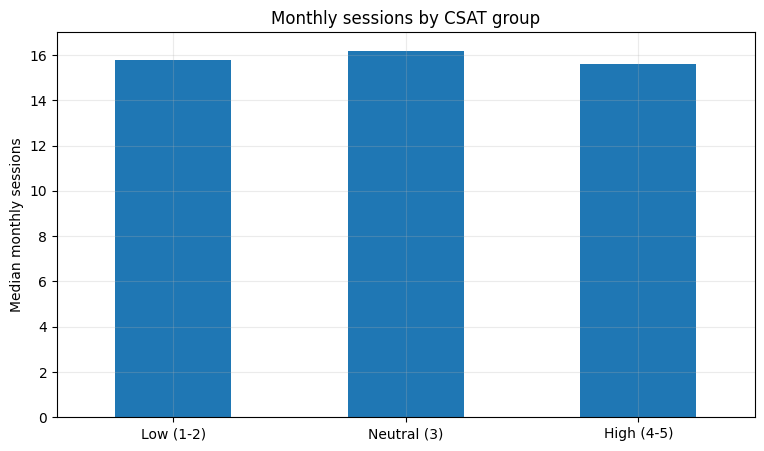

In [17]:
usage_by_csat["median_monthly_sessions"].plot(kind="bar")
plt.title("Monthly sessions by CSAT group")
plt.xlabel("")
plt.ylabel("Median monthly sessions")
plt.xticks(rotation=0)
plt.show()


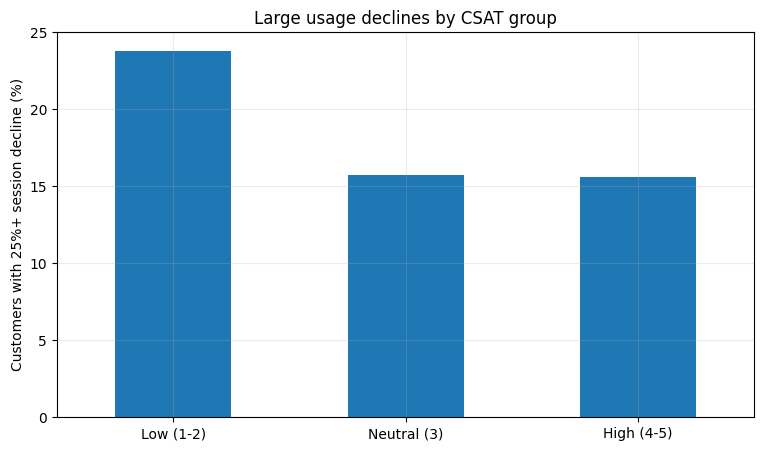

In [18]:
usage_by_csat["usage_decline_pct"].plot(kind="bar")
plt.title("Large usage declines by CSAT group")
plt.xlabel("")
plt.ylabel("Customers with 25%+ session decline (%)")
plt.xticks(rotation=0)
plt.show()


### Important

This shows **association**, not causation.

The usage data runs from Jan–May 2023, while the support tickets are around the end of May / start of June. So this dataset is better for asking whether low-CSAT customers already had different engagement patterns before / around support contact, not whether support caused later churn.


## 4. Are Premium / Enterprise customers more valuable?

There is no revenue field, so we cannot measure customer value directly.

For EDA, we'll use **engagement as a value proxy**:
- monthly sessions
- actions
- products used
- collaborators
- integrations


In [19]:
customer_full = (
    customers
    .merge(customer_usage, on="Customer ID", how="left")
    .merge(customer_csat, on="Customer ID", how="left")
)

plan_value = (
    customer_full.groupby("Plan Type")
    .agg(
        customers=("Customer ID", "count"),
        median_monthly_sessions=("avg_monthly_sessions", "median"),
        median_monthly_actions=("avg_monthly_actions", "median"),
        median_products_used=("products_used", "median"),
        median_collaborators=("avg_monthly_collaborators", "median"),
        median_integrations=("avg_monthly_integrations", "median"),
        avg_csat=("avg_csat", "mean"),
        critical_ticket_pct=(
            "critical_tickets",
            lambda x: (x.fillna(0) >= 1).mean() * 100
        ),
        usage_decline_pct=(
            "usage_decline_25",
            lambda x: x.mean() * 100
        )
    )
    .round(2)
)

plan_value


,customers,median_monthly_sessions,median_monthly_actions,median_products_used,median_collaborators,median_integrations,avg_csat,critical_ticket_pct,usage_decline_pct
Plan Type,,,,,,,,,
Enterprise,1202,21.00,121.30,1.00,11.80,6.00,3.04,25.21,13.48
Free,1472,9.80,55.30,1.00,9.80,1.20,3.01,26.49,27.11
Premium,2337,18.80,106.20,1.00,11.60,4.00,3.00,25.07,14.89
Standard,3309,15.20,86.20,1.00,11.00,2.40,2.96,25.42,18.59


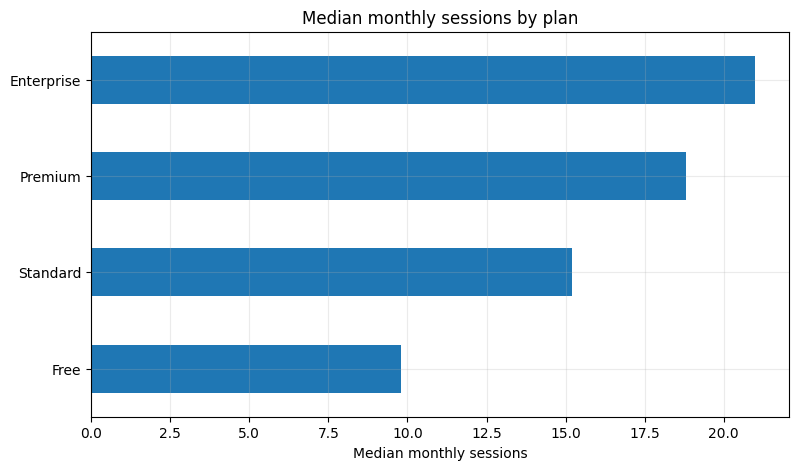

In [20]:
plan_value["median_monthly_sessions"].sort_values().plot(kind="barh")
plt.title("Median monthly sessions by plan")
plt.xlabel("Median monthly sessions")
plt.ylabel("")
plt.show()


In [21]:
plan_value[["avg_csat", "critical_ticket_pct", "usage_decline_pct"]]


,avg_csat,critical_ticket_pct,usage_decline_pct
Plan Type,,,
Enterprise,3.04,25.21,13.48
Free,3.01,26.49,27.11
Premium,3.00,25.07,14.89
Standard,2.96,25.42,18.59


This lets us check whether higher-tier plans have stronger engagement **and** whether they are disproportionately exposed to support problems.

## 5. Which segment gives us the clearest story?

Now combine plan + company size.

The most useful segment is usually one that is:
- large enough to matter
- highly engaged / valuable
- showing weak support outcomes or falling usage


In [22]:
# Customer-level support flags
customer_full["poor_support"] = (
    (customer_full["avg_csat"] <= 2)
    | (customer_full["critical_tickets"].fillna(0) >= 1)
)

customer_full["combined_flag"] = (
    customer_full["poor_support"]
    & customer_full["usage_decline_25"]
)

segment_story = (
    customer_full.groupby(["Plan Type", "Company Size"])
    .agg(
        customers=("Customer ID", "count"),
        median_monthly_sessions=("avg_monthly_sessions", "median"),
        median_products_used=("products_used", "median"),
        avg_csat=("avg_csat", "mean"),
        poor_support_customers=("poor_support", "sum"),
        poor_support_pct=("poor_support", "mean"),
        usage_decline_customers=("usage_decline_25", "sum"),
        usage_decline_pct=("usage_decline_25", "mean"),
        combined_flagged=("combined_flag", "sum"),
        combined_flag_pct=("combined_flag", "mean")
    )
    .reset_index()
)

for col in [
    "poor_support_pct",
    "usage_decline_pct",
    "combined_flag_pct"
]:
    segment_story[col] *= 100

segment_story = segment_story.round(2)

segment_story.sort_values(
    ["combined_flagged", "combined_flag_pct"],
    ascending=False
).head(15)


,Plan Type,Company Size,customers,median_monthly_sessions,median_products_used,avg_csat,poor_support_customers,poor_support_pct,usage_decline_customers,usage_decline_pct,combined_flagged,combined_flag_pct
23,Standard,51-200,913,15.20,1.00,2.84,358,39.21,164,17.96,69,7.56
20,Standard,11-50,697,14.80,1.00,3.12,236,33.86,138,19.80,54,7.75
11,Free,51-200,390,9.80,1.00,3.03,136,34.87,105,26.92,43,11.03
9,Free,201-500,281,10.40,1.00,2.81,122,43.42,76,27.05,41,14.59
14,Premium,11-50,518,18.80,1.00,3.03,180,34.75,87,16.80,41,7.92
21,Standard,201-500,596,14.80,1.00,3.02,214,35.91,111,18.62,38,6.38
8,Free,11-50,321,9.80,1.00,3.02,105,32.71,88,27.41,33,10.28
18,Standard,1-10,370,17.00,1.00,2.99,134,36.22,64,17.30,32,8.65
17,Premium,51-200,665,19.00,1.00,2.87,220,33.08,87,13.08,30,4.51
15,Premium,201-500,428,18.60,1.00,3.20,156,36.45,70,16.36,26,6.07


## Only show reasonably large segments

In [23]:
large_segments = (
    segment_story[segment_story["customers"] >= 100]
    .sort_values(
        ["combined_flag_pct", "combined_flagged"],
        ascending=False
    )
)

large_segments.head(15)


,Plan Type,Company Size,customers,median_monthly_sessions,median_products_used,avg_csat,poor_support_customers,poor_support_pct,usage_decline_customers,usage_decline_pct,combined_flagged,combined_flag_pct
9,Free,201-500,281,10.40,1.00,2.81,122,43.42,76,27.05,41,14.59
6,Free,1-10,145,9.00,1.00,2.98,47,32.41,47,32.41,18,12.41
11,Free,51-200,390,9.80,1.00,3.03,136,34.87,105,26.92,43,11.03
10,Free,501-1000,164,9.60,1.00,3.50,48,29.27,39,23.78,17,10.37
8,Free,11-50,321,9.80,1.00,3.02,105,32.71,88,27.41,33,10.28
18,Standard,1-10,370,17.00,1.00,2.99,134,36.22,64,17.30,32,8.65
7,Free,1000+,171,9.80,1.00,2.95,71,41.52,44,25.73,14,8.19
14,Premium,11-50,518,18.80,1.00,3.03,180,34.75,87,16.80,41,7.92
20,Standard,11-50,697,14.80,1.00,3.12,236,33.86,138,19.80,54,7.75
13,Premium,1000+,251,19.00,1.00,2.78,96,38.25,39,15.54,19,7.57


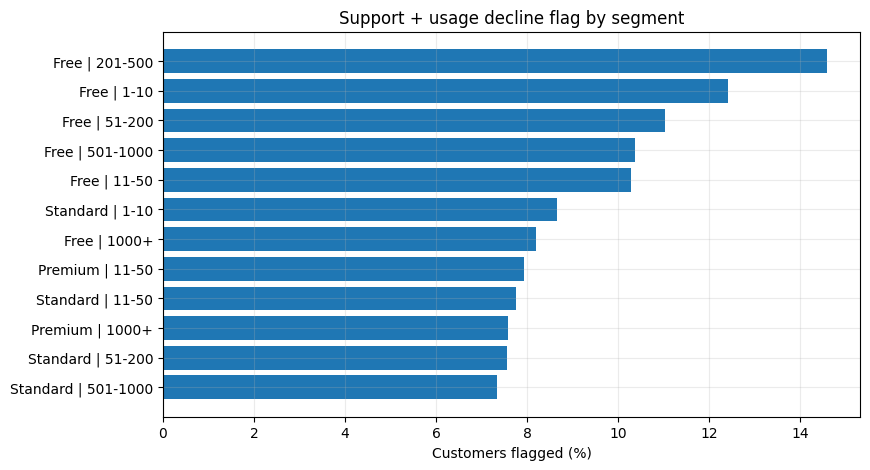

In [24]:
plot_segments = large_segments.head(12).copy()
plot_segments["segment"] = (
    plot_segments["Plan Type"]
    + " | "
    + plot_segments["Company Size"]
)

plot_segments = plot_segments.sort_values("combined_flag_pct")

plt.barh(
    plot_segments["segment"],
    plot_segments["combined_flag_pct"]
)

plt.title("Support + usage decline flag by segment")
plt.xlabel("Customers flagged (%)")
plt.ylabel("")
plt.show()


## Which segment affects the most actual customers?

In [25]:
segment_story[
    [
        "Plan Type",
        "Company Size",
        "customers",
        "combined_flagged",
        "combined_flag_pct",
        "avg_csat",
        "median_monthly_sessions"
    ]
].sort_values(
    "combined_flagged",
    ascending=False
).head(15)


,Plan Type,Company Size,customers,combined_flagged,combined_flag_pct,avg_csat,median_monthly_sessions
23,Standard,51-200,913,69,7.56,2.84,15.20
20,Standard,11-50,697,54,7.75,3.12,14.80
11,Free,51-200,390,43,11.03,3.03,9.80
9,Free,201-500,281,41,14.59,2.81,10.40
14,Premium,11-50,518,41,7.92,3.03,18.80
21,Standard,201-500,596,38,6.38,3.02,14.80
8,Free,11-50,321,33,10.28,3.02,9.80
18,Standard,1-10,370,32,8.65,2.99,17.00
17,Premium,51-200,665,30,4.51,2.87,19.00
15,Premium,201-500,428,26,6.07,3.20,18.60


## Quick product × plan check

This can uncover something more specific like:

> "Enterprise Jira users have a noticeably worse support experience"

instead of a very broad plan-level story.


In [26]:
product_plan = (
    tickets_customer.groupby(["Product Purchased", "Plan Type"])
    .agg(
        tickets=("Ticket ID", "count"),
        customers=("Customer ID", "nunique"),
        avg_csat=("Customer Satisfaction Rating", "mean"),
        low_csat_pct=(
            "Customer Satisfaction Rating",
            lambda x: (x.dropna() <= 2).mean() * 100
            if x.notna().any() else np.nan
        ),
        critical_pct=(
            "Ticket Priority",
            lambda x: (x == "Critical").mean() * 100
        )
    )
    .reset_index()
    .round(2)
)

product_plan[
    product_plan["tickets"] >= 50
].sort_values(
    ["low_csat_pct", "tickets"],
    ascending=[False, False]
).head(20)


,Product Purchased,Plan Type,tickets,customers,avg_csat,low_csat_pct,critical_pct
0,Bitbucket,Enterprise,238,238,2.85,45.95,23.53
17,Trello,Free,302,301,2.83,44.74,27.15
7,Confluence,Standard,729,727,2.95,42.52,23.73
3,Bitbucket,Standard,639,638,2.94,42.40,25.35
15,Loom,Standard,664,664,2.97,41.59,27.11
10,Jira,Premium,527,523,2.88,41.46,22.96
12,Loom,Enterprise,231,231,3.00,41.46,24.24
11,Jira,Standard,679,677,2.95,41.20,22.83
19,Trello,Standard,656,654,3.00,40.09,26.52
2,Bitbucket,Premium,467,463,2.96,39.74,24.41


## Final summary tables

In [27]:
print("PLAN SUPPORT")
display(plan_support)

print("\nCOMPANY SIZE SUPPORT")
display(company_support)

print("\nPRODUCT SUPPORT")
display(product_support)

print("\nUSAGE BY CSAT")
display(usage_by_csat)

print("\nPLAN ENGAGEMENT / SUPPORT")
display(plan_value)

print("\nTOP CUSTOMER SEGMENTS")
display(large_segments.head(10))


PLAN SUPPORT


,customers,tickets,avg_csat,low_csat_pct,critical_pct,closed_pct,tickets_per_customer
Plan Type,,,,,,,
Standard,3309,3367,2.96,41.55,25.07,32.88,1.02
Premium,2337,2383,2.99,38.52,24.72,32.35,1.02
Free,1472,1506,3.02,38.96,26.03,33.07,1.02
Enterprise,1202,1213,3.04,38.42,25.06,32.40,1.01



COMPANY SIZE SUPPORT


,customers,tickets,avg_csat,low_csat_pct,critical_pct,closed_pct,tickets_per_customer
Company Size,,,,,,,
51-200,2322,2365,2.91,42.97,25.92,33.07,1.02
1000+,950,973,2.92,40.94,23.12,30.63,1.02
1-10,875,891,3.02,38.65,23.12,31.65,1.02
201-500,1502,1522,3.04,39.16,27.00,34.56,1.01
501-1000,896,911,3.04,37.87,23.82,33.04,1.02
11-50,1775,1807,3.06,37.07,25.29,32.10,1.02



PRODUCT SUPPORT


...

,customers,median_monthly_sessions,mean_monthly_sessions,median_monthly_actions,median_products_used,median_integrations,median_session_change_pct,usage_decline_pct
csat_group,,,,,,,,
Low (1-2),1088,15.80,17.55,89.60,1.00,2.80,-7.69,23.81
Neutral (3),584,16.20,18.25,92.30,1.00,3.00,0.00,15.75
High (4-5),1077,15.60,17.98,89.40,1.00,2.80,0.00,15.60



PLAN ENGAGEMENT / SUPPORT


,customers,median_monthly_sessions,median_monthly_actions,median_products_used,median_collaborators,median_integrations,avg_csat,critical_ticket_pct,usage_decline_pct
Plan Type,,,,,,,,,
Enterprise,1202,21.00,121.30,1.00,11.80,6.00,3.04,25.21,13.48
Free,1472,9.80,55.30,1.00,9.80,1.20,3.01,26.49,27.11
Premium,2337,18.80,106.20,1.00,11.60,4.00,3.00,25.07,14.89
Standard,3309,15.20,86.20,1.00,11.00,2.40,2.96,25.42,18.59



TOP CUSTOMER SEGMENTS


,Plan Type,Company Size,customers,median_monthly_sessions,median_products_used,avg_csat,poor_support_customers,poor_support_pct,usage_decline_customers,usage_decline_pct,combined_flagged,combined_flag_pct
9,Free,201-500,281,10.40,1.00,2.81,122,43.42,76,27.05,41,14.59
6,Free,1-10,145,9.00,1.00,2.98,47,32.41,47,32.41,18,12.41
11,Free,51-200,390,9.80,1.00,3.03,136,34.87,105,26.92,43,11.03
10,Free,501-1000,164,9.60,1.00,3.50,48,29.27,39,23.78,17,10.37
8,Free,11-50,321,9.80,1.00,3.02,105,32.71,88,27.41,33,10.28
18,Standard,1-10,370,17.00,1.00,2.99,134,36.22,64,17.30,32,8.65
7,Free,1000+,171,9.80,1.00,2.95,71,41.52,44,25.73,14,8.19
14,Premium,11-50,518,18.80,1.00,3.03,180,34.75,87,16.80,41,7.92
20,Standard,11-50,697,14.80,1.00,3.12,236,33.86,138,19.80,54,7.75
13,Premium,1000+,251,19.00,1.00,2.78,96,38.25,39,15.54,19,7.57
